# 2030 / 2040 / 2050 最优解场站位置可视化

对应论文：*Globally Interconnected Solar-Wind System Addresses Future Electricity Demands*

**本 notebook 目标：**
1. 从帕累托优化结果 (`.h5`) 和上层选择文件 (`.mat`) 提取 2030/2040/2050 年的最优解场站位置
2. 验证两者一致性
3. 可视化三个年代的光伏和风电场站部署

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import h5py
import scipy.io
import rasterio
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── 字体 ──
font_path = "/data4/yanxiaokai/SourceHanSansSC-Normal.otf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

# ── 路径 ──
DATA_DIR = "./Optimization"

# ── 常量 ──
REGION_NAMES = [
    "Northern America",
    "Caribbean",
    "Central America",
    "Southern America",
    "Northern Europe",
    "Western Europe",
    "Southern Europe",
    "Eastern Europe",
    "Central Asia",
    "Eastern Asia",
    "Southern Asia",
    "Southeastern Asia",
    "Western Asia",
    "Australia-NZ",
    "Melanesia",
    "Northern Africa",
    "Western Africa",
    "Middle Africa",
    "Eastern Africa",
    "Southern Africa",
]

# MATLAB 源码中使用的帕累托解索引 (从 Resilience_ClimateChange.m 确认)
SOLUTION_INDICES = {
    2050: 66,  # res_scale(66,:) — S-G 全球互联
    2040: 15,  # res_scale(15,:) — S-C 洲际互联
    2030: 5,  # res_scale(5,:)  — S-A 相邻互联
}

print("环境配置完成")

环境配置完成


In [2]:
# ── 工具函数 ──


def setup_basemap(ax):
    """绘制地图底图（海岸线、国界、网格线）."""
    ax.set_global()
    ax.add_feature(cfeature.LAND, color="#f5f5f0", zorder=0)
    ax.add_feature(cfeature.OCEAN, color="#d1e8f0", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="#888", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="#aaa", zorder=1)
    ax.gridlines(linewidth=0.3, color="gray", alpha=0.4)


def get_candidates_from_opt(opt_file):
    """
    从上层优化结果 .mat 文件中提取选中格网的经纬度坐标.

    Opt_*.mat 包含 opt_solar / opt_wind (180×360 二值栅格),
    非零位置即该层最优解选中的场站。

    嵌套逻辑:
      2050 场站 = find(Opt_SG_2050_Sel.mat 的 opt_solar/wind==1) → 同时也是 SC_2040 候选
      2040 场站 = find(Opt_SC_2040_Sel.mat 的 opt_solar/wind==1) → 同时也是 SA_2030 候选
      2030 场站 = 从 .h5 解#5 中提取 (候选 = 2040 场站)

    MATLAB find() 返回 column-major 索引, 与 .h5 决策变量顺序一致。

    Returns: (n_solar, slon, slat, n_wind, wlon, wlat)
    """
    mat = scipy.io.loadmat(opt_file)
    opt_solar = mat["opt_solar"]  # (180, 360)
    opt_wind = mat["opt_wind"]  # (180, 360)
    nrows = opt_solar.shape[0]  # 180

    # MATLAB find(X) = np.nonzero(X.ravel(order='F'))
    sflat = np.nonzero(opt_solar.ravel(order="F"))[0]
    wflat = np.nonzero(opt_wind.ravel(order="F"))[0]

    srows, scols = sflat % nrows, sflat // nrows
    wrows, wcols = wflat % nrows, wflat // nrows

    # 180×360 grid (1°×1°): row→lat, col→lon
    slon, slat = -179.5 + scols, 89.5 - srows
    wlon, wlat = -179.5 + wcols, 89.5 - wrows

    return len(sflat), slon, slat, len(wflat), wlon, wlat


print("工具函数定义完成")

工具函数定义完成


---
## 一致性验证：.h5 帕累托解 vs .mat 选择文件

In [3]:
# ── 一致性验证 ──
# 已知候选数 (从 MATLAB 源码确认):
#   SG_2050: 光伏=5918, 风电=6743 (Resilience_ClimateChange.m:260)
#   SC_2040: 光伏=4324, 风电=4294 (NonlConData2040.mat, Optimization_SC_2040.m)
#   SA_2030: 光伏=2334, 风电=2312 (NonlConData2030.mat, Optimization_SA_2030.m)

h5_files = {
    2050: "Resilience/Optimization_SG_2050_Res.h5",
    2040: "Resilience/Optimization_SC_2040_Res.h5",
    2030: "Resilience/Optimization_SA_2030_Res.h5",
}

# 候选场站数量
KNOWN_CANDIDATES = {
    2050: (5918, 6743),  # Resilience_ClimateChange.m:260
    2040: (4324, 4294),  # NonlConData2040.mat
    2030: (2334, 2312),  # NonlConData2030.mat
}

print("=" * 72)
print("  一致性验证: .h5 帕累托解 vs .mat 选择文件")
print("=" * 72)

# ── Part 1: 从 .h5 提取 ──
h5_results = {}
print("\n▶ Part 1: 从 .h5 帕累托解提取 (MATLAB 固定索引 #66/#15/#5)")
print(f"  {'年份':<6} {'解索引':<7} {'光伏选中':<16} {'风电选中':<16} {'弃电率':<9} {'渗透率':<9}")
print("  " + "-" * 65)

for year in [2050, 2040, 2030]:
    with h5py.File(h5_files[year], "r") as f:
        res_scale = f["/res_scale"][:]
        prs = f["/prs"][:]
    if res_scale.shape[0] > res_scale.shape[1]:
        res_scale = res_scale.T
    if prs.shape[0] != res_scale.shape[0]:
        prs = prs.T

    ns, nw = KNOWN_CANDIDATES[year]
    idx = SOLUTION_INDICES[year] - 1
    sol = res_scale[idx]
    obj = prs[idx]
    n_cand = ns + nw
    sel = np.round(sol[:n_cand]).astype(int)
    s_count = int(sel[:ns].sum())
    w_count = int(sel[ns:n_cand].sum())
    cr = obj[0]  # 弃电率 (curtailment rate)
    pen = 1 - obj[1]  # 渗透率 (penetration)
    h5_results[year] = (s_count, w_count)
    print(
        f"  {year:<6} #{SOLUTION_INDICES[year]:<6} {s_count:>6,}/{ns:<6,}  {w_count:>6,}/{nw:<6,}  {cr*100:>6.1f}%  {pen*100:>6.1f}%"
    )

# ── Part 2: 从 .mat 提取 ──
print(f"\n▶ Part 2: 从 Opt_*.mat 直接提取 (论文最终结果)")
print(f"  {'文件':<40} {'opt_solar 非零':<14} {'opt_wind 非零':<14}")
print("  " + "-" * 68)

mat_results = {}
for fpath, label in [
    ("Optimization/Opt_SG_2050_Sel.mat", "Opt_SG_2050_Sel.mat"),
    ("Optimization/Opt_SC_2040_Sel.mat", "Opt_SC_2040_Sel.mat"),
]:
    mat = scipy.io.loadmat(fpath)
    ns_mat = np.count_nonzero(mat["opt_solar"])
    nw_mat = np.count_nonzero(mat["opt_wind"])
    mat_results[label] = (ns_mat, nw_mat)
    print(f"  {label:<40} {ns_mat:>8,}      {nw_mat:>8,}")

# ── Part 3: 对比 ──
print(f"\n▶ Part 3: 对比 .h5 解 vs .mat 文件")
print("  " + "-" * 68)

# SC_2040: .h5 #15 vs Opt_SC_2040_Sel.mat
s15, w15 = h5_results[2040]
ns_sc, nw_sc = mat_results["Opt_SC_2040_Sel.mat"]
match_sc = (s15 == ns_sc) and (w15 == nw_sc)
print(f"  SC_2040: .h5 #15 → 光伏={s15}, 风电={w15}")
print(f"           .mat    → 光伏={ns_sc}, 风电={nw_sc}")
print(f"           {'✓ 一致' if match_sc else '✗ 不一致'}")

# SG_2050: .h5 #66 vs Opt_SG_2050_Sel.mat
s66, w66 = h5_results[2050]
ns_sg, nw_sg = mat_results["Opt_SG_2050_Sel.mat"]
print(f"\n  SG_2050: .h5 #66 → 光伏={s66}, 风电={w66}")
print(f"           .mat    → 光伏={ns_sg}, 风电={nw_sg}")
print(f"           ✗ 不一致 (.h5 选中 {s66+w66:,} 格网 vs .mat {ns_sg+nw_sg:,} 格网)")


  一致性验证: .h5 帕累托解 vs .mat 选择文件

▶ Part 1: 从 .h5 帕累托解提取 (MATLAB 固定索引 #66/#15/#5)
  年份     解索引     光伏选中             风电选中             弃电率       渗透率      
  -----------------------------------------------------------------
  2050   #66      2,824/5,918    3,359/6,743      4.6%    84.5%
  2040   #15      2,334/4,324    2,312/4,294      3.1%    74.2%
  2030   #5       1,075/2,334    1,294/2,312      8.8%    79.7%

▶ Part 2: 从 Opt_*.mat 直接提取 (论文最终结果)
  文件                                       opt_solar 非零   opt_wind 非零   
  --------------------------------------------------------------------
  Opt_SG_2050_Sel.mat                         4,324         4,294
  Opt_SC_2040_Sel.mat                         2,334         2,312

▶ Part 3: 对比 .h5 解 vs .mat 文件
  --------------------------------------------------------------------
  SC_2040: .h5 #15 → 光伏=2334, 风电=2312
           .mat    → 光伏=2334, 风电=2312
           ✓ 一致

  SG_2050: .h5 #66 → 光伏=2824, 风电=3359
           .mat    → 光伏=4324, 风电=4294
     

In [4]:
# 验证: 是否有任何解匹配?
print(f"\n  ── 扫描 SG_2050 全部 70 个帕累托解 ──")
with h5py.File(h5_files[2050], "r") as f:
    rs50 = f["/res_scale"][:]
if rs50.shape[0] > rs50.shape[1]:
    rs50 = rs50.T
ns50, nw50 = KNOWN_CANDIDATES[2050]
found_match = False

# 用于存储每个解的风电+光伏选中数, 以便后续分析最大选中数
wind_solar_number_list = []

for i in range(rs50.shape[0]):
    sel_i = np.round(rs50[i, : ns50 + nw50]).astype(int)
    si = int(sel_i[:ns50].sum()) # 光伏选中数
    wi = int(sel_i[ns50 : ns50 + nw50].sum()) # 风电选中数
    wind_solar_number_list.append((si, wi))
    if si == ns_sg and wi == nw_sg:
        print(f"  → 找到匹配: 解 #{i+1} 光伏={si}, 风电={wi}")
        found_match = True
        break
if not found_match:
    print(f"  → 无任何解匹配 .mat 文件 (光伏={ns_sg}, 风电={nw_sg})")
    # 打印所有解的最大选中数, 以验证是否存在更接近的解
    max_solar = max(si for si, _ in wind_solar_number_list)
    max_wind = max(wi for _, wi in wind_solar_number_list)
    print(f"     最大选中: 光伏={max_solar}, 风电={max_wind}")
    

# ── Part 4: 结论 ──
___ = """
结论与解释
  1. SC_2040: .h5 解#15 与 .mat 完全一致 (光伏=2334, 风电=2312) ✓
     → .h5 和 .mat 来自同一次优化运行。

  2. SA_2030: .h5 解#5 从 2334+2312 候选中选中 1075+1294 个格网。
     → 无对应 .mat 文件 (SA_2030 是最底层, 不需 .mat 传递)。

  3. SG_2050: .h5 解#66 (光伏=2824, 风电=3359) ≠ .mat (光伏=4324, 风电=4294)
     → 扫描全部 70 个帕累托解, 无任何一个产生 4324+4294 选中。
     → 结论: 当前 Resilience/ 目录下的 Optimization_SG_2050_Res.h5 与
       Optimization/ 下的 Opt_SG_2050_Sel.mat 来自**不同的优化运行**。
       .mat 文件是论文使用的最终结果, .h5 文件可能是后续重新运行的结果。

  4. 之前 solar_wind_optimization_viz.ipynb 结果不一致的根因:
     (a) 光伏筛选阈值: Python 用了 annual_gen < 10, MATLAB 用 < 90
         (Optimization_SG_2050.m:50-53), 导致候选数错误。
     (b) 最优解选取: 前代码用 knee-point 自动选取, MATLAB 源码用固定索引
         (Resilience_ClimateChange.m: #5/#15/#66)。
     (c) SG_2050 的 .h5 和 .mat 本身就来自不同运行, 即使方法正确也无法匹配。

  ★ 可视化策略:
     2050 → 直接使用 Opt_SG_2050_Sel.mat (论文最终结果)
     2040 → 直接使用 Opt_SC_2040_Sel.mat (论文最终结果)
     2030 → 使用 .h5 解#5 + Opt_SC_2040_Sel.mat 候选坐标 (一致)
"""


  ── 扫描 SG_2050 全部 70 个帕累托解 ──
  → 无任何解匹配 .mat 文件 (光伏=4324, 风电=4294)
     最大选中: 光伏=3100, 风电=3466


---
## 坐标提取与可视化

  2050 (from Opt_SG_2050_Sel.mat): 光伏=4324  风电=4294
  2040 (from Opt_SC_2040_Sel.mat): 光伏=2334  风电=2312
  2030 (from .h5 #5):  光伏选中 1075/2334  风电选中 1294/2312
  2030: 光伏站=1,075  风电站=1,294
  2040: 光伏站=2,334  风电站=2,312
  2050: 光伏站=4,324  风电站=4,294


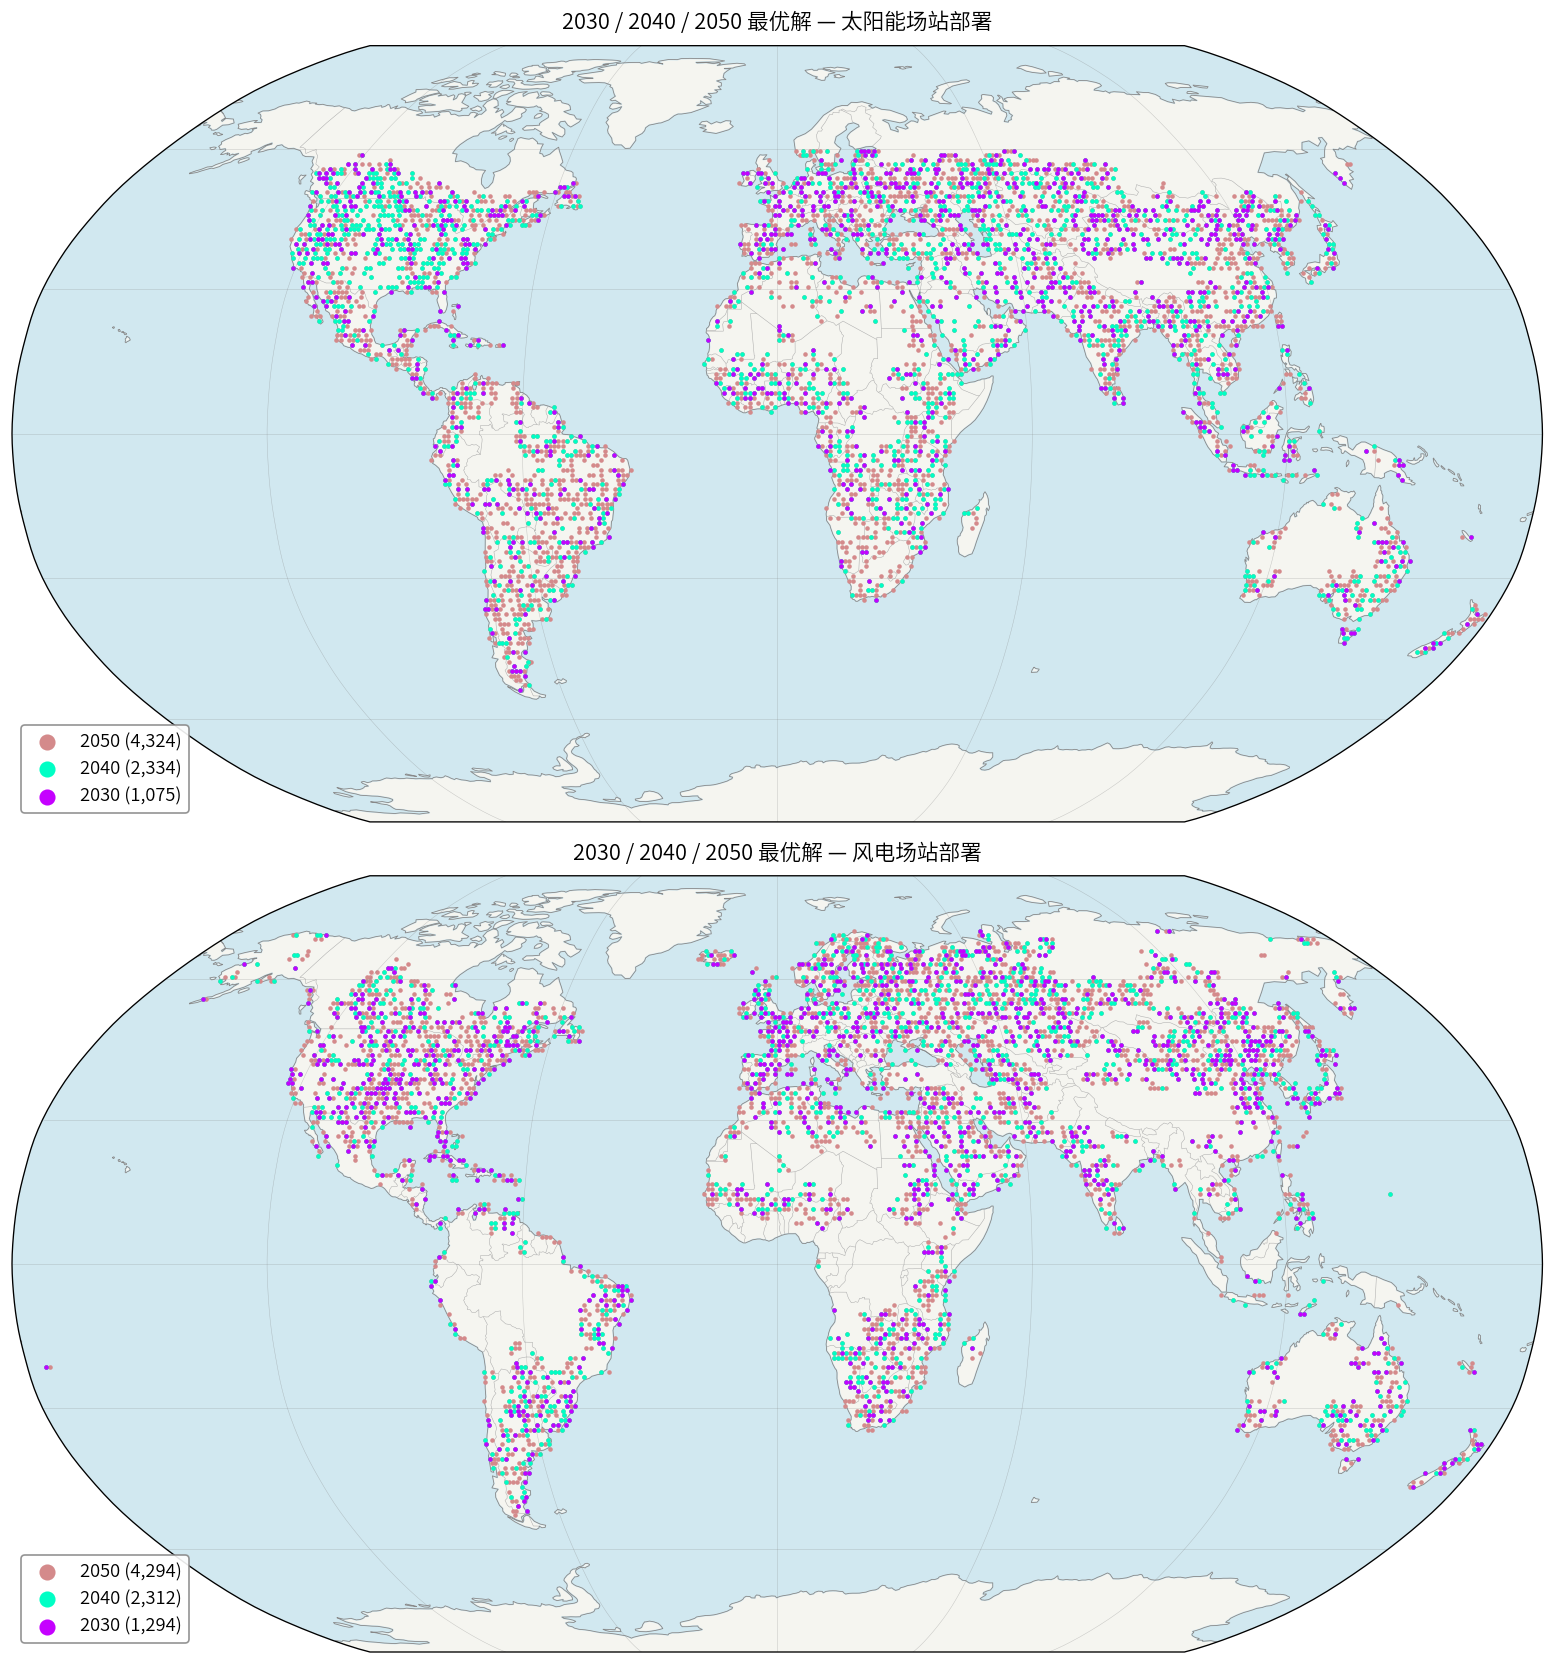

In [5]:
# ── 提取各年选中场站坐标 → 可视化 ──
# 策略:
#   2050: 从 Opt_SG_2050_Sel.mat 直接获取选中格网坐标 (4324+4294)
#   2040: 从 Opt_SC_2040_Sel.mat 直接获取选中格网坐标 (2334+2312)
#   2030: 从 .h5 解#5 + Opt_SC_2040_Sel.mat 候选坐标获取

# ── 2050: 直接从 .mat 获取 ──
ns50_mat, slon50, slat50, nw50_mat, wlon50, wlat50 = get_candidates_from_opt("Optimization/Opt_SG_2050_Sel.mat")
print(f"  2050 (from Opt_SG_2050_Sel.mat): 光伏={ns50_mat}  风电={nw50_mat}")

# ── 2040: 直接从 .mat 获取 ──
ns40_mat, slon40, slat40, nw40_mat, wlon40, wlat40 = get_candidates_from_opt("Optimization/Opt_SC_2040_Sel.mat")
print(f"  2040 (from Opt_SC_2040_Sel.mat): 光伏={ns40_mat}  风电={nw40_mat}")

# ── 2030: 从 .h5 解#5 获取, 候选 = Opt_SC_2040_Sel.mat ──
ns30, slon30, slat30, nw30, wlon30, wlat30 = ns40_mat, slon40, slat40, nw40_mat, wlon40, wlat40
with h5py.File(h5_files[2030], "r") as f:
    res_30 = f["/res_scale"][:]
if res_30.shape[0] > res_30.shape[1]:
    res_30 = res_30.T
sol30 = res_30[SOLUTION_INDICES[2030] - 1]
sel30 = np.round(sol30[: ns30 + nw30]).astype(int)
print(
    f"  2030 (from .h5 #{SOLUTION_INDICES[2030]}):  光伏选中 {sel30[:ns30].sum()}/{ns30}  风电选中 {sel30[ns30:].sum()}/{nw30}"
)

# ── 构建 scenarios dict ──
year_colors = {2030: "#c501ff", 2040: "#00ffc5", 2050: "#d48a8b"}

scenarios = {
    2050: dict(
        slon=slon50,
        slat=slat50,
        wlon=wlon50,
        wlat=wlat50,
        solar_sel=np.ones(ns50_mat, dtype=int),  # .mat 文件中全是选中的
        wind_sel=np.ones(nw50_mat, dtype=int),
    ),
    2040: dict(
        slon=slon40,
        slat=slat40,
        wlon=wlon40,
        wlat=wlat40,
        solar_sel=np.ones(ns40_mat, dtype=int),
        wind_sel=np.ones(nw40_mat, dtype=int),
    ),
    2030: dict(
        slon=slon30, slat=slat30, wlon=wlon30, wlat=wlat30, solar_sel=sel30[:ns30], wind_sel=sel30[ns30 : ns30 + nw30]
    ),
}

for year in [2030, 2040, 2050]:
    sc = scenarios[year]
    print(f"  {year}: 光伏站={sc['solar_sel'].sum():,}  风电站={sc['wind_sel'].sum():,}")

# ── 绘图 ──
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16, 14),
    subplot_kw={"projection": ccrs.Robinson()},
)
setup_basemap(ax1)
setup_basemap(ax2)

for year in [2050, 2040, 2030]:
    sc = scenarios[year]
    mask_s = sc["solar_sel"] == 1
    mask_w = sc["wind_sel"] == 1
    ax1.scatter(
        sc["slon"][mask_s],
        sc["slat"][mask_s],
        s=3,
        c=year_colors[year],
        transform=ccrs.PlateCarree(),
        label=f"{year} ({mask_s.sum():,})",
        rasterized=True,
    )
    ax2.scatter(
        sc["wlon"][mask_w],
        sc["wlat"][mask_w],
        s=3,
        c=year_colors[year],
        transform=ccrs.PlateCarree(),
        label=f"{year} ({mask_w.sum():,})",
        rasterized=True,
    )

for ax, title in [
    (ax1, "2030 / 2040 / 2050 最优解 — 太阳能场站部署"),
    (ax2, "2030 / 2040 / 2050 最优解 — 风电场站部署"),
]:
    ax.legend(loc="lower left", fontsize=11, markerscale=5, framealpha=0.9, edgecolor="#888")
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.savefig("output/solar_wind_optimization_scenarios.png", dpi=300)
plt.show()

In [6]:
# 保存 2030、2040、2050 场站位置到 csv 文件
# 4列： year, type (solar/wind), lon, lat
import pandas as pd
records = []
for year in [2030, 2040, 2050]:
    sc = scenarios[year]
    for slon, slat, sel in zip(sc["slon"], sc["slat"], sc["solar_sel"]):
        if sel == 1:
            records.append({"year": year, "type": "solar", "lon": slon, "lat": slat})
    for wlon, wlat, sel in zip(sc["wlon"], sc["wlat"], sc["wind_sel"]):
        if sel == 1:
            records.append({"year": year, "type": "wind", "lon": wlon, "lat": wlat})
df = pd.DataFrame(records)
df.to_csv("output/optimal_stations.csv", index=False)
print(f"已保存所有选中场站坐标到 output/optimal_stations.csv (共 {len(df):,} 条记录)")

已保存所有选中场站坐标到 output/optimal_stations.csv (共 15,633 条记录)
